# White Light Interferogram Simulator (Last Week Version)
This notebook contains the version where:
- The NumPy white-light interferogram simulation worked.
- The LightPipes Michelson demo produced fringes.
- BeamMix was called correctly with two LightPipes `Field` objects.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


## Load heightmap from CSV

In [2]:
def load_heightmap(filename="heightmap.csv"):
    data = pd.read_csv(filename)

    max_x = int(data["x"].max()) + 1
    max_y = int(data["y"].max()) + 1
    Z = np.zeros((max_y, max_x))

    for _, row in data.iterrows():
        x = int(row["x"])
        y = int(row["y"])
        z = row["z"]
        Z[y, x] = z
    return Z

try:
    heightmap = load_heightmap("heightmap.csv")
    print("Loaded heightmap.csv, shape:", heightmap.shape)
except FileNotFoundError:
    size = 64
    x = np.linspace(-1, 1, size)
    X, Y = np.meshgrid(x, x)
    heightmap = 0.5 * np.exp(-(X**2 + Y**2) / 0.2)
    print("Using synthetic Gaussian surface, shape:", heightmap.shape)


Using synthetic Gaussian surface, shape: (64, 64)


## WLI Parameters and Helper Functions

In [3]:
lambda0 = 600.0   # central wavelength (nm)
Lc = 100.0        # coherence length (nm)
s_range = np.linspace(-300, 300, 200)  # reference mirror scan (nm)

def _to_nm(z_surface, scale=100.0):
    """Convert height in arbitrary units to nm."""
    return scale * z_surface

def _expand_for_broadcast(z_surface_nm, s_range):
    z_exp = z_surface_nm[:, :, np.newaxis]         # (y, x, 1)
    s_exp = s_range[np.newaxis, np.newaxis, :]     # (1, 1, s)
    return z_exp, s_exp


## Spectral White-Light Interferogram (NumPy model)

In [4]:
def simulate_interferogram(z_surface, lambda0=600.0, Lc=100.0, s_range=None,
                           n_wl=41, V0=0.9, background=0.0, camera_noise=0.0,
                           height_scale=1.0, tilt_amount_nm=0.0):
    """
    Spectrally-integrated white-light interferogram (Michelson-like).
    Returns I(y,x,s) and s_range.
    """
    if s_range is None:
        s_range = np.linspace(-300, 300, 200)

    # 1) geometry / OPD
    z_surface_nm = _to_nm(z_surface)               # (Ny, Nx) in nm
    z_exp, s_exp = _expand_for_broadcast(z_surface_nm, s_range)  # (Ny,Nx,Ns)

    # Height-following Michelson OPD
    OPD = 2.0 * (height_scale * z_exp - s_exp)    # (Ny,Nx,Ns) in nm

    # optional tilt (straight fringes)
    if tilt_amount_nm != 0.0:
        Ny, Nx = z_surface_nm.shape
        x = np.linspace(-1.0, 1.0, Nx)
        y = np.linspace(-1.0, 1.0, Ny)
        X, Y = np.meshgrid(x, y)
        OPD = OPD + tilt_amount_nm * X[:, :, None]

    # 2) spectrum from coherence length (Gaussian spectrum)
    delta_lambda_fwhm = (lambda0**2) / (Lc + 1e-12)
    sigma_lambda = delta_lambda_fwhm / (2.0*np.sqrt(2.0*np.log(2.0)))

    wl = np.linspace(lambda0 - 2*delta_lambda_fwhm,
                     lambda0 + 2*delta_lambda_fwhm,
                     n_wl)

    S = np.exp(-0.5 * ((wl - lambda0)/sigma_lambda)**2)
    S /= S.sum()

    # 3) spectral integration
    I = np.zeros_like(OPD, dtype=float)
    for w, weight in zip(wl, S):
        phase = (2.0 * np.pi / w) * OPD
        I += weight * (1.0 + V0 * np.cos(phase))

    # 4) background + noise
    if background:
        I += background

    if camera_noise and camera_noise > 0:
        I += np.random.normal(scale=camera_noise, size=I.shape)

    return I, s_range


## Run NumPy WLI Simulation and Plot

I shape: (64, 64, 200)


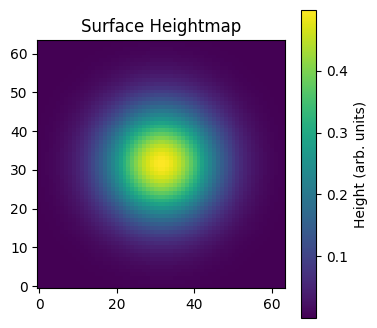

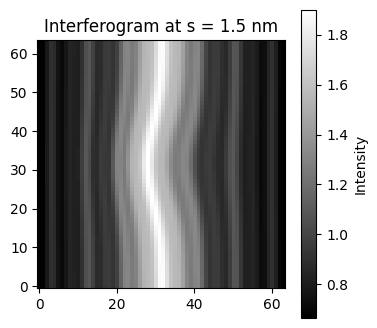

In [5]:
I, s_range = simulate_interferogram(heightmap, lambda0, Lc, s_range, tilt_amount_nm=800.0)
print("I shape:", I.shape)

# heightmap
plt.figure(figsize=(4,4))
plt.imshow(heightmap, cmap="viridis", origin="lower", aspect="equal")
plt.colorbar(label="Height (arb. units)")
plt.title("Surface Heightmap")
plt.show()

# one interferogram slice
idx = len(s_range)//2
plt.figure(figsize=(4,4))
plt.imshow(I[:,:,idx], cmap="gray", origin="lower")
plt.colorbar(label="Intensity")
plt.title(f"Interferogram at s = {s_range[idx]:.1f} nm")
plt.show()


## LightPipes Michelson Interferometer Demo (Last Week Version)

In [6]:
try:
    from LightPipes import *

    wavelength_lp = lambda0 * nm
    ny, nx = heightmap.shape
    pixel_size_um = 30.0
    size_lp = max(nx, ny) * pixel_size_um * um
    N_lp = int(max(256, max(nx, ny)))

    # convert heightmap -> scaled phase screen
    z_nm_lp = _to_nm(heightmap)
    phase_rad_lp = (4*np.pi/lambda0) * z_nm_lp
    phase_rad_lp -= np.mean(phase_rad_lp)
    phase_rad_lp *= 0.05   # reduce roughness for cleaner fringes

    ph_up = np.resize(phase_rad_lp, (N_lp, N_lp)).astype(float)

    Rbs = 0.5
    tilt_angle = 5 * mrad

    frames_lp = []
    N_panels = 9
    s_idxs_lp = np.linspace(0, len(s_range)-1, N_panels, dtype=int)
    s_vals_lp = s_range[s_idxs_lp]

    for s_val in s_vals_lp:
        scan_phase = (-4*np.pi/lambda0) * float(s_val)

        # base field
        F0 = Begin(size_lp, wavelength_lp, N_lp)
        F0 = GaussBeam(F0, size_lp/6)

        # sample arm with phase
        F_sample = IntAttenuator(F0, 1-Rbs)
        F_sample = SubPhase(F_sample, ph_up)

        # reference arm with tilt + OPD scan
        F_ref = IntAttenuator(F0, Rbs)
        F_ref = Tilt(F_ref, tilt_angle, 0)
        F_ref = Phase(F_ref, scan_phase)  # scalar phase

        # interfere
        Fcomb = BeamMix(F_ref, F_sample)
        I_lp = np.array(Intensity(Fcomb))
        frames_lp.append((s_val, I_lp))

    # plot frames
    fig, axes = plt.subplots(3,3, figsize=(10,10))
    axes_flat = axes.flat
    for ax, (s_val, img) in zip(axes_flat, frames_lp):
        ax.imshow(img, cmap='gray', origin='lower')
        ax.set_title(f"LP Michelson: s = {s_val:.1f} nm")
        ax.axis('off')
    for ax in list(axes_flat)[len(frames_lp):]:
        fig.delaxes(ax)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("LightPipes demo not available or failed:", e)


LightPipes demo not available or failed: 'numpy.ndarray' object has no attribute 'field'


## Series Plot: NumPy Interferogram Frames

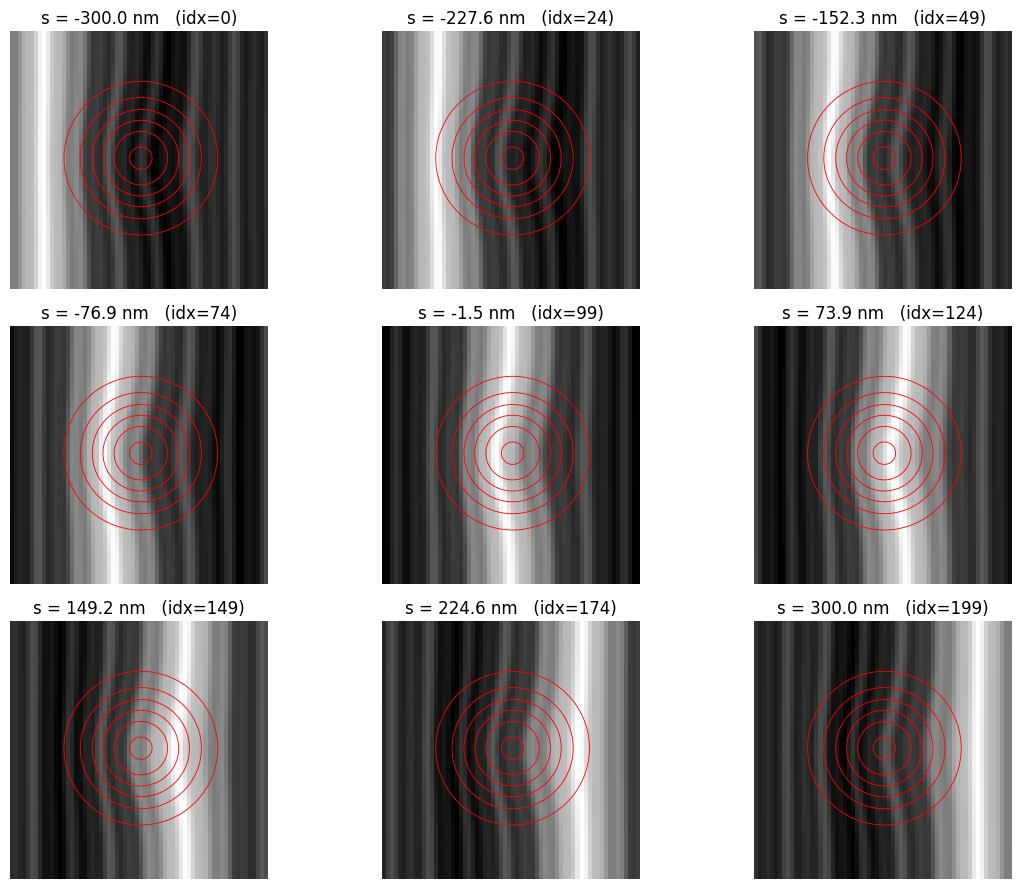

In [7]:
try:
    assert I.ndim == 3

    if 'plot_s_values' in globals() and plot_s_values is not None:
        s_vals = np.asarray(plot_s_values, dtype=float)
        idxs = [int(np.argmin(np.abs(s_range - sv))) for sv in s_vals]
    else:
        N_panels = 9
        idxs = np.linspace(0, len(s_range)-1, N_panels, dtype=int).tolist()

    n = len(idxs)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
    axes_flat = axes.flat if hasattr(axes, 'flat') else [axes]

    im = None
    for ax, idx in zip(axes_flat, idxs):
        im = ax.imshow(I[:, :, idx], cmap='gray', origin='lower')
        ax.set_title(f's = {s_range[idx]:.1f} nm   (idx={idx})')
        if 'heightmap' in globals():
            try:
                cs = ax.contour(heightmap, levels=6, colors='r', linewidths=0.6, origin='lower')
            except Exception:
                pass
        ax.axis('off')

    for ax in list(axes_flat)[n:]:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()
except AssertionError as aerr:
    print(aerr)
except Exception as e:
    print('Series plot failed:', e)
